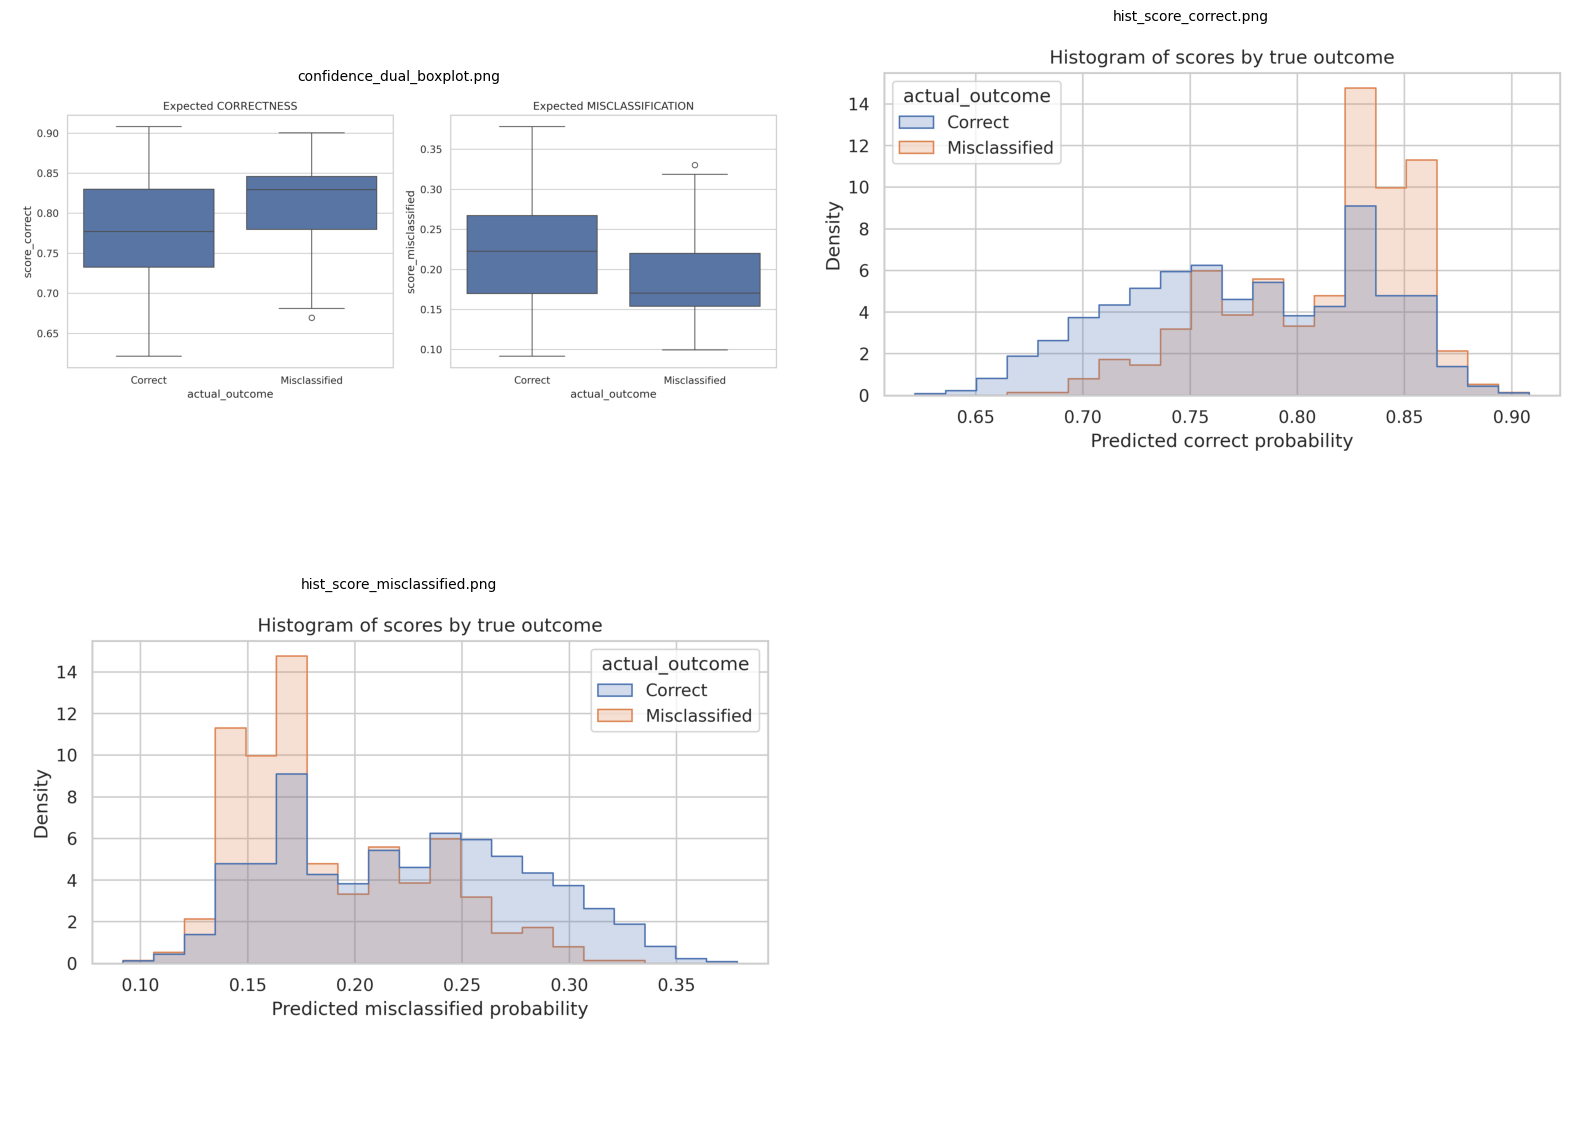

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import math

# === CONFIGURATION: set manually each time you want to view another combination ===
threshold = '0.1'       # e.g., '0.1', '0.2', ..., '0.9'
significance = 'yes'    # 'yes' or 'no'
coef = 'negative'       # 'positive' or 'negative'

# === PATH CONSTRUCTION ===
base = Path(f"{threshold}_threshold_experiment")
folder = f"whole_whole_coef-{coef}_sig-{significance}"
png_dir = base / folder / "evaluation_results"

png_files = sorted(png_dir.glob("*.png"))

if not png_files:
    print(f"No PNGs found in {png_dir.resolve()}")
else:
    n = len(png_files)
    cols = 2  # set number of columns in grid
    rows = math.ceil(n / cols)
    fig_width = 8 * cols
    fig_height = 6 * rows
    
    fig, axs = plt.subplots(rows, cols, figsize=(fig_width, fig_height))
    
    # Make axs always a 2D array for consistent indexing
    axs = axs.reshape(rows, cols) if n > 1 else [[axs]]
    
    img_idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axs[r][c]
            if img_idx < n:
                img = mpimg.imread(png_files[img_idx])
                ax.imshow(img, aspect='equal')
                ax.axis('off')
                ax.set_title(png_files[img_idx].name, fontsize=10)
                img_idx += 1
            else:
                ax.axis('off')  # empty cell
                
    plt.tight_layout()
    plt.show()